In [ ]:
# 01 — Seaborn Basics (Preetham's Seaborn Mastery Series)

Part 1 of 5:
1. **Basics** (this notebook)
2. Categorical Plots
3. Distribution Plots
4. Regression & Matrix Plots
5. Real-World Titanic EDA

Seaborn is built on top of Matplotlib — it adds statistical plotting, built-in themes, and works directly with pandas DataFrames.

## 1. What is Seaborn?

- Built on top of Matplotlib by **Michael Waskom**.
- Designed for **statistical visualization** — works directly with DataFrames and automatically handles grouping, color mapping, and legends.
- Comes with built-in example datasets (`tips`, `titanic`, `iris`, `penguins`, `flights`) — no CSV hunting needed for practice.
- Two plot families: **figure-level** (e.g. `relplot`, `catplot`, `displot` — return a whole Figure/Grid) and **axes-level** (e.g. `scatterplot`, `boxplot` — plot onto a single Axes, combine freely with Matplotlib).

In [1]:
!pip install seaborn --quiet

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('Seaborn version:', sns.__version__)

Seaborn version: 0.13.2


## 2. Loading Built-in Datasets

In [3]:
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
print('Available built-in datasets:', sns.get_dataset_names()[:15])

Available built-in datasets: ['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris']


## 3. Themes — `sns.set_theme()`

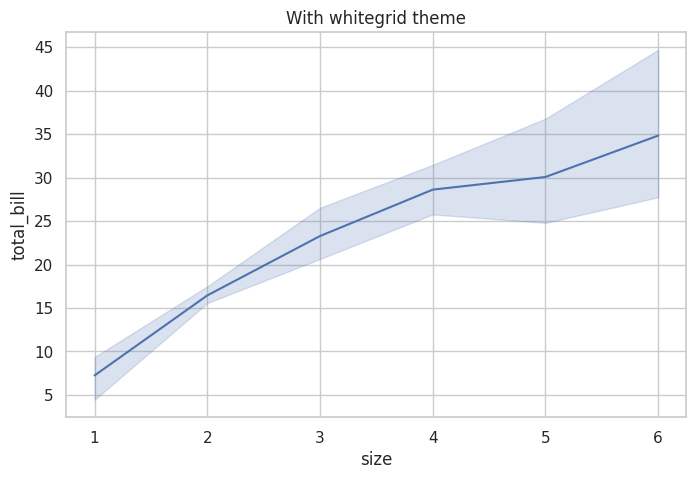

In [5]:
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x='size', y='total_bill', data=tips, ax=ax)
ax.set_title('With whitegrid theme')
plt.show()

## 4. Comparing All Built-in Styles

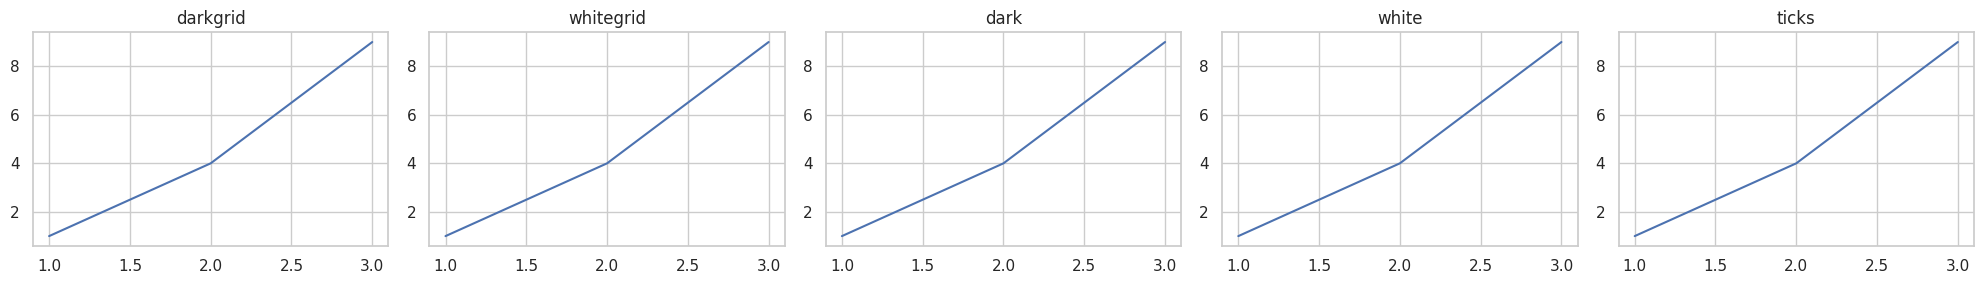

In [6]:
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for ax, style in zip(axes, styles):
    sns.set_style(style)
    ax.plot([1,2,3], [1,4,9])
    ax.set_title(style)
plt.tight_layout()
plt.show()
sns.set_theme(style='whitegrid')

## 5. `scatterplot()` — Axes-Level Scatter

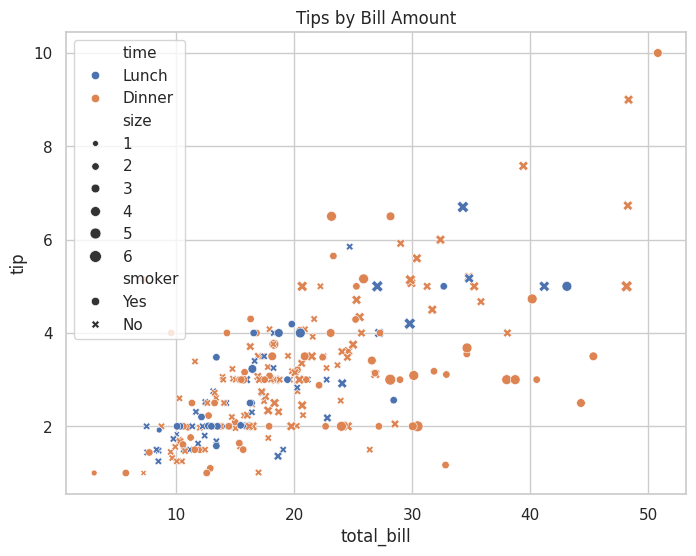

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=tips, hue='time', style='smoker', size='size', ax=ax)
ax.set_title('Tips by Bill Amount')
plt.show()

## 6. `lineplot()` — With Automatic Confidence Interval

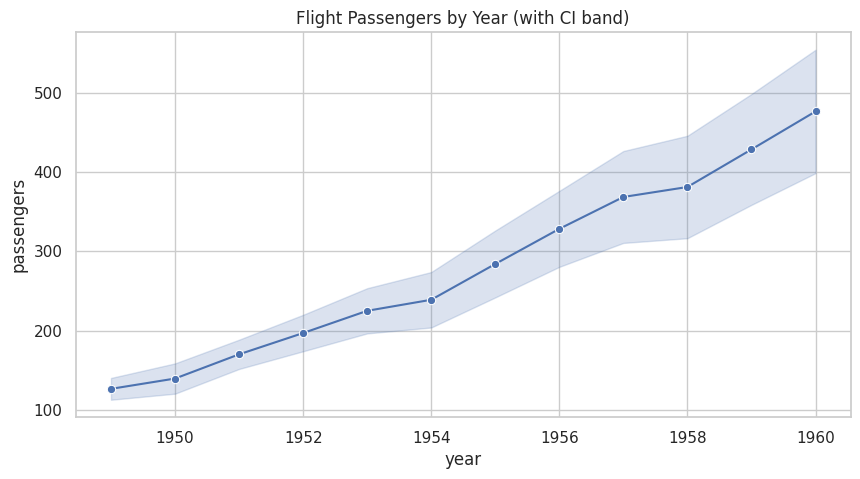

In [8]:
flights = sns.load_dataset('flights')
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(x='year', y='passengers', data=flights, ax=ax, marker='o', errorbar='sd')
ax.set_title('Flight Passengers by Year (with CI band)')
plt.show()

## 7. `relplot()` — Figure-Level Relationship Plot with Facets

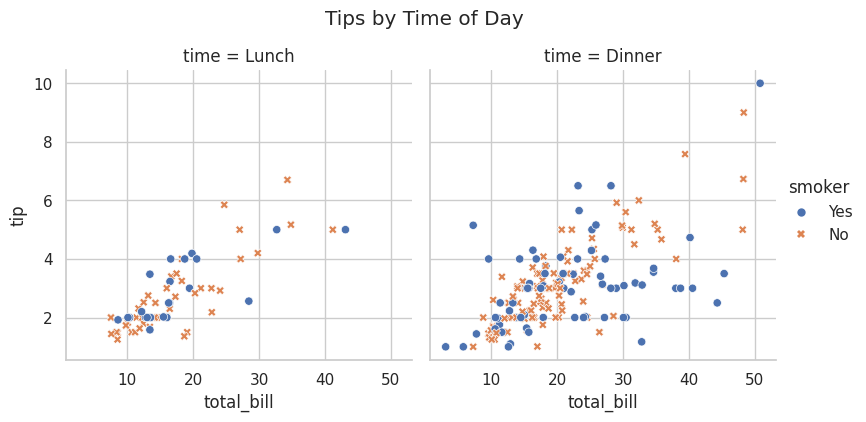

In [9]:
g = sns.relplot(x='total_bill', y='tip', data=tips, col='time', hue='smoker', style='smoker', kind='scatter', height=4)
g.fig.suptitle('Tips by Time of Day', y=1.05)
plt.show()

## 8. Color Palettes

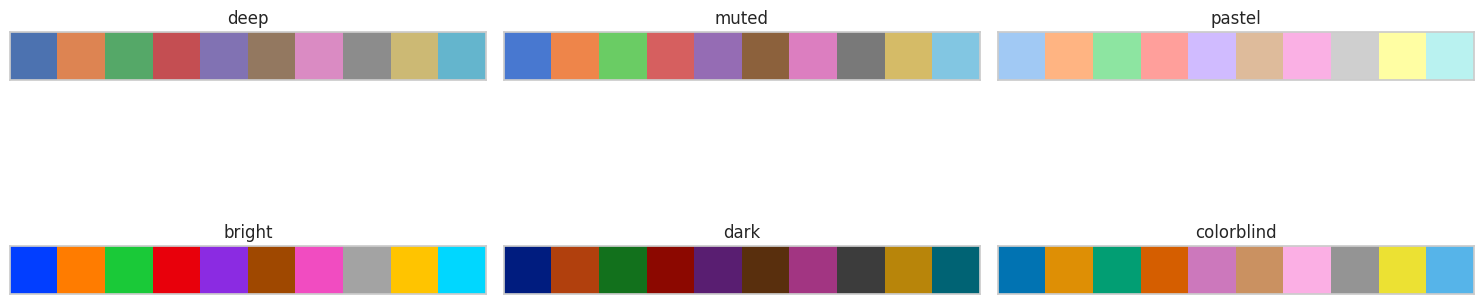

In [10]:
palettes = ['deep', 'muted', 'pastel', 'bright', 'dark', 'colorblind']
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for ax, pal in zip(axes.flat, palettes):
    colors = sns.color_palette(pal)
    ax.imshow([colors])
    ax.set_title(pal)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 9. Custom Color Palettes

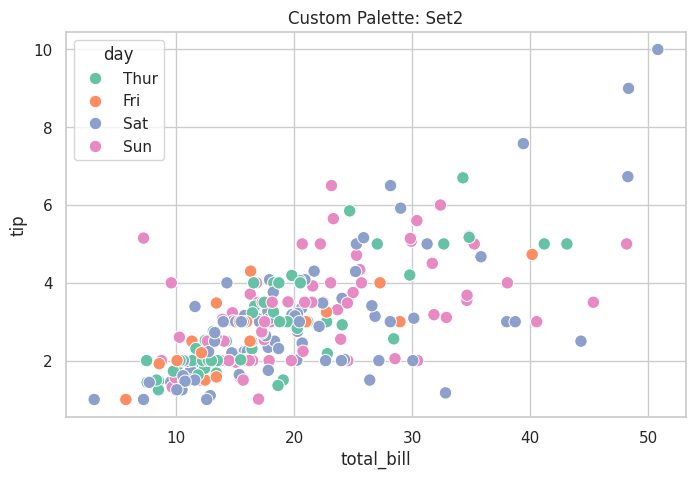

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x='total_bill', y='tip', data=tips, hue='day', palette='Set2', ax=ax, s=80)
ax.set_title('Custom Palette: Set2')
plt.show()

## 10. Removing Spines — `sns.despine()`

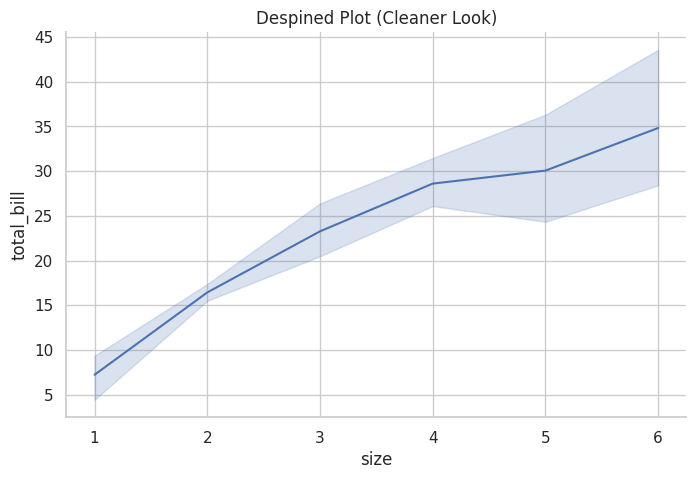

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x='size', y='total_bill', data=tips, ax=ax)
sns.despine(ax=ax)
ax.set_title('Despined Plot (Cleaner Look)')
plt.show()

## 11. Context Control — `sns.set_context()` for Presentation Sizing

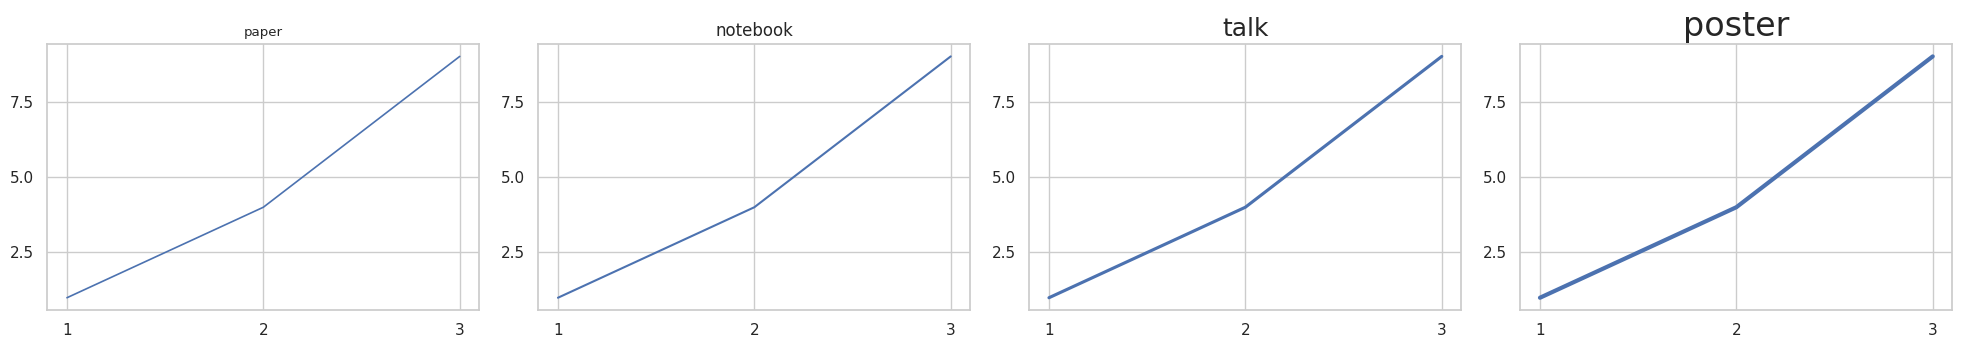

In [13]:
contexts = ['paper', 'notebook', 'talk', 'poster']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, ctx in zip(axes, contexts):
    sns.set_context(ctx)
    sns.lineplot(x=[1,2,3], y=[1,4,9], ax=ax)
    ax.set_title(ctx)
plt.tight_layout()
plt.show()
sns.set_context('notebook')

## 12. Faceting with `FacetGrid` — Manual Control

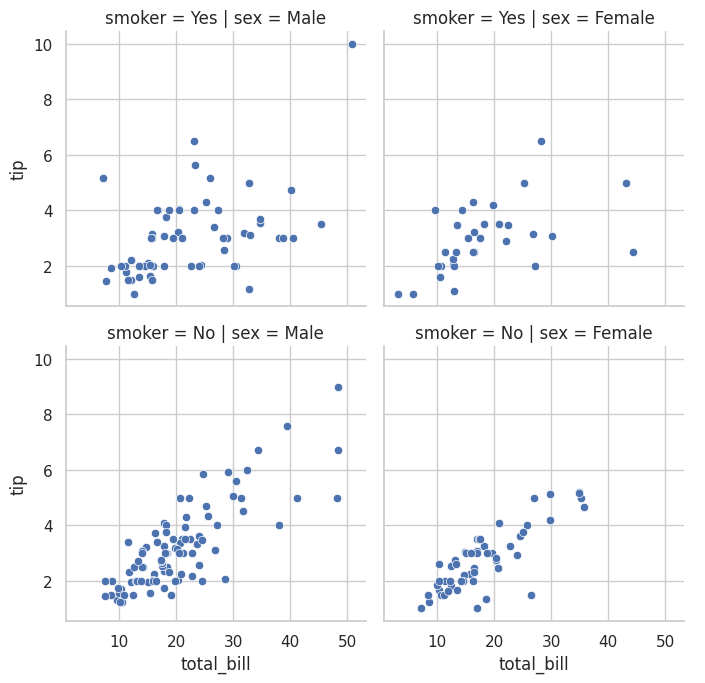

In [14]:
g = sns.FacetGrid(tips, col='sex', row='smoker', height=3.5)
g.map(sns.scatterplot, 'total_bill', 'tip')
g.add_legend()
plt.show()

## 13. Summary — What You Learned

- Seaborn's relationship to Matplotlib and pandas
- Built-in datasets, themes, styles, contexts
- `scatterplot()`, `lineplot()` (axes-level) vs `relplot()` (figure-level)
- Color palettes, despine, faceting with FacetGrid

### Next Notebook
Continue to **`02_categorical_plots.ipynb`** for bar, box, violin, strip, swarm, and point plots.